In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import importlib
import module
importlib.reload(module)

<module 'module' from 'C:\\Users\\Admin\\Desktop\\computational finance\\finance computation with python\\Neuer Ordner\\module.py'>

In [4]:
# DOWNLOAD DATA

benchmark_ticker = "AOR"

download_tickers = [
    "SPY",
    "XLE",
    "ITA",
    benchmark_ticker
]

tickers = [
    "SPY_VIX",
    "XLE_OIL",
    "ITA_DEF",
    benchmark_ticker
]

vix_ticker = "^VIX"
vix3m_ticker = "^VIX3M"
oil_ticker = "CL=F"
xlu_ticker = "XLU"
xlp_ticker = "XLP"

indicator_tickers = [
    vix_ticker,
    vix3m_ticker,
    oil_ticker,
    xlu_ticker,
    xlp_ticker
]

start_date = "2015-01-01"
end_date = "2025-12-31"

df_downloaded_prices, _ = module.download_stock_price_data(
    download_tickers,
    start_date,
    end_date
)

df_indicator_prices, _ = module.download_stock_price_data(
    indicator_tickers,
    start_date,
    end_date
)

common_index = df_downloaded_prices.index.intersection(
    df_indicator_prices.index
)

df_downloaded_prices = df_downloaded_prices.loc[common_index]
df_indicator_prices = df_indicator_prices.loc[common_index]

df_prices = pd.DataFrame(index=common_index)

df_prices["SPY_VIX"] = df_downloaded_prices["SPY"]
df_prices["XLE_OIL"] = df_downloaded_prices["XLE"]
df_prices["ITA_DEF"] = df_downloaded_prices["ITA"]
df_prices[benchmark_ticker] = df_downloaded_prices[benchmark_ticker]

df_price_changes = module.price_changes_from_price_frame(df_prices)

print("First common date:", df_prices.index.min())
print("Last common date:", df_prices.index.max())

df_prices.tail()

First common date: 2015-01-02 00:00:00
Last common date: 2025-12-30 00:00:00


,SPY_VIX,XLE_OIL,ITA_DEF,AOR
date,,,,
2025-12-23,684.323303,44.211136,219.393494,64.908707
2025-12-24,686.730530,44.081982,219.902802,65.097801
2025-12-26,686.660889,43.913086,217.775681,65.127663
2025-12-29,684.213867,44.330357,216.707123,65.038086
2025-12-30,683.378357,44.668152,216.048019,65.008232


In [5]:
# DEFINE THREE TRADING SIGNALS

# Signal 0:
# Trades SPY using VIX term structure and SPY momentum.

# Signal 1:
# Trades XLE using crude oil momentum, XLE trend, XLE momentum,
# and XLE relative strength versus SPY.

# Signal 2:
# Trades ITA using defensive-sector and volatility conditions.

Signal 1 is an oil and energy relative-strength signal.

The strategy trades XLE. Crude oil futures and SPY are not traded directly; they are only used as information variables.

The idea is that energy equities should perform better when the energy sector is in an upward trend, crude oil momentum is supportive, and XLE is not underperforming the broad equity market.

The XLE trend condition is:

$$
XLE_t > MA_t^{XLE,200}
$$

The oil momentum condition is:

$$
M_t^{Oil}
=
\frac{Oil_t}{Oil_{t-126}} - 1
>
-0.05
$$

The XLE momentum condition is:

$$
M_t^{XLE}
=
\frac{XLE_t}{XLE_{t-210}} - 1
>
0
$$

The relative strength ratio is:

$$
RS_t^{XLE/SPY}
=
\frac{XLE_t}{SPY_t}
$$

The relative strength momentum condition is:

$$
M_t^{RS}
=
\frac{RS_t^{XLE/SPY}}{RS_{t-21}^{XLE/SPY}} - 1
>
0
$$

The final signal is:

$$
S_t^{XLE}
=
\begin{cases}
1, & \text{if all four conditions are satisfied} \\
0, & \text{otherwise}
\end{cases}
$$

In [6]:
signal_0_ratio_threshold = 1.10
signal_0_momentum_window = 168
signal_0_momentum_threshold = -0.025


def signal_0(series):

    return module.vix_term_structure_signal(
        target_series=series,
        vix_series=df_indicator_prices[vix_ticker],
        vix3m_series=df_indicator_prices[vix3m_ticker],
        ratio_threshold=signal_0_ratio_threshold,
        momentum_window=signal_0_momentum_window,
        momentum_threshold=signal_0_momentum_threshold
    )

Signal 1 is a gold regime signal.

The strategy buys GLD when gold is trending upward and Treasury bonds also show positive momentum.

$$
M_t^{GLD}=
\frac{GLD_t}{GLD_{t-m_1}}-1
$$

$$
M_t^{TLT}=
\frac{TLT_t}{TLT_{t-b_1}}-1
$$

$$
S_t^{(1)}=1
$$

if

$$
GLD_t > MA_t^{GLD}
$$

and

$$
M_t^{GLD}>q_1
$$

and

$$
M_t^{TLT}>r_1
$$

Otherwise,

$$
S_t^{(1)}=0
$$

In [7]:
signal_1_trend_window = 200

signal_1_oil_momentum_window = 126
signal_1_oil_momentum_threshold = -0.05

signal_1_target_momentum_window = 210
signal_1_target_momentum_threshold = 0.0

signal_1_relative_strength_window = 21
signal_1_relative_strength_threshold = -0.025


def signal_1(series):

    return module.oil_energy_relative_strength_signal(
        target_series=series,
        oil_series=df_indicator_prices[oil_ticker],
        market_series=df_downloaded_prices["SPY"],
        trend_window=signal_1_trend_window,
        oil_momentum_window=signal_1_oil_momentum_window,
        oil_momentum_threshold=signal_1_oil_momentum_threshold,
        target_momentum_window=signal_1_target_momentum_window,
        target_momentum_threshold=signal_1_target_momentum_threshold,
        relative_strength_window=signal_1_relative_strength_window,
        relative_strength_threshold=signal_1_relative_strength_threshold
    )

Signal 2 is a defensive volatility signal.

The strategy buys ITA when ITA has positive own strength and defensive conditions are present.

$$
M_t^{ITA/SPY}=
\frac{ITA_t/SPY_t}{ITA_{t-m_2}/SPY_{t-m_2}}-1
$$

$$
D_t=
\frac{(XLU_t+XLP_t)/2}{SPY_t}
$$

$$
S_t^{(2)}=1
$$

if ITA trend and relative strength are positive and defensive market conditions are present.

Otherwise,

$$
S_t^{(2)}=0
$$

In [8]:
signal_2_trend_window = 150
signal_2_ita_momentum_window = 63
signal_2_ita_momentum_threshold = 0.025
signal_2_relative_strength_window = 168
signal_2_relative_strength_threshold =  -0.025
signal_2_vix_average_window = 42
signal_2_defensive_momentum_window = 126
signal_2_defensive_momentum_threshold = -0.025


def signal_2(series):

    return module.ita_defensive_volatility_signal(
        ita_series=series,
        spy_series=df_downloaded_prices["SPY"],
        vix_series=df_indicator_prices[vix_ticker],
        xlu_series=df_indicator_prices[xlu_ticker],
        xlp_series=df_indicator_prices[xlp_ticker],
        trend_window=signal_2_trend_window,
        ita_momentum_window=signal_2_ita_momentum_window,
        ita_momentum_threshold=signal_2_ita_momentum_threshold,
        relative_strength_window=signal_2_relative_strength_window,
        relative_strength_threshold=signal_2_relative_strength_threshold,
        vix_average_window=signal_2_vix_average_window,
        defensive_momentum_window=signal_2_defensive_momentum_window,
        defensive_momentum_threshold=signal_2_defensive_momentum_threshold
    )

In [9]:
signals = {
    tickers[0]: signal_0(df_prices[tickers[0]]),
    tickers[1]: signal_1(df_prices[tickers[1]]),
    tickers[2]: signal_2(df_prices[tickers[2]])
}

execution_delay_days = 1

for ticker in tickers[:-1]:

    signals[ticker] = module.apply_execution_delay(
        signals[ticker],
        delay_days=execution_delay_days
    )

df_position_open = pd.concat([
    signals[tickers[0]]["signal"].rename(tickers[0]),
    signals[tickers[1]]["signal"].rename(tickers[1]),
    signals[tickers[2]]["signal"].rename(tickers[2])
], axis=1)

df_position_changes = pd.concat([
    signals[tickers[0]]["position_change"].rename(tickers[0]),
    signals[tickers[1]]["position_change"].rename(tickers[1]),
    signals[tickers[2]]["position_change"].rename(tickers[2])
], axis=1)

df_position_open.tail()

,SPY_VIX,XLE_OIL,ITA_DEF
date,,,
2025-12-23,1.0,0.0,0.0
2025-12-24,1.0,0.0,0.0
2025-12-26,1.0,0.0,0.0
2025-12-29,1.0,0.0,0.0
2025-12-30,1.0,0.0,0.0


In [10]:
# ALLOCATE CAPITAL AND COMPUTE RESULTING POSITIONS
initial_cash = 1.0
capital_fraction_per_trade = 0.30

# DO NOT MODIFY THIS CELL BELOW THIS LINE
position = []

def open_trades(position, position_change):
    vec = np.maximum([position_change[ticker] for ticker in tickers[:-1]], [0])
    vec = position[-1] * (1 - np.power((1 - capital_fraction_per_trade), np.sum(vec))) * vec / (1 if (np.nansum(vec) == 0.0) else np.nansum(vec))
    return np.append(vec + position[:-1], position[-1] - np.sum(vec))

def hold_trades(position, price_change):
    return np.concatenate((position[:-1] * price_change[:-1], [position[-1]]))

def close_trades(position, position_change):
    vec = np.concatenate((np.array([position_change[ticker] < 0.0 for ticker in tickers[:-1]]), [False]))
    position[-1] = position[-1] + np.sum(position[vec])
    position[vec] = 0.0
    return position
    
is_first = True
for idx, position_change in df_position_changes.iterrows():
    if is_first:
        position.append(open_trades(np.concatenate((np.zeros(len(df_position_changes.columns)), [initial_cash])), position_change))
        is_first = False
    else:
        hlpr_pos = hold_trades(position[-1], df_price_changes.loc[[idx]].to_numpy()[0])
        hlpr_pos = close_trades(hlpr_pos, position_change)
        position.append(open_trades(hlpr_pos, position_change))

df_position = pd.DataFrame(position, index = df_prices.index, columns = tickers[:-1] + ['cash'])

In [11]:
statistics_rows = {}

portfolio_value = df_position.sum(axis=1).to_numpy(dtype=float)

statistics_rows["Combined Strategy"] = (
    module.performance_statistics_from_values(
        portfolio_value
    )
)

benchmark_values = df_prices[tickers[-1]].to_numpy(dtype=float)

benchmark_curve = (
    benchmark_values
    / benchmark_values[0]
)

statistics_rows["Benchmark"] = (
    module.performance_statistics_from_values(
        benchmark_curve
    )
)

df_statistics = pd.DataFrame(statistics_rows).T

df_statistics = df_statistics[
    [
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Max Drawdown"
    ]
]

df_statistics.round(4)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Combined Strategy,0.0418,0.0500,0.8427,-0.0778
Benchmark,0.0711,0.1049,0.7077,-0.2295


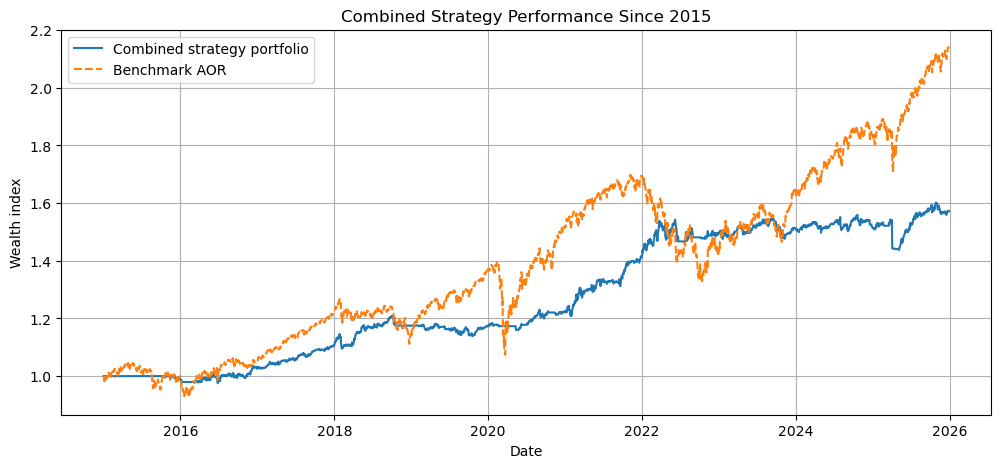

In [12]:
# COMPUTE MEANINGFUL PLOTS OF YOUR STRATEGY AND LABEL THEM IN AN UNDERSTANDABLE WAY

portfolio_value = df_position.sum(axis=1).to_numpy(dtype=float)

portfolio_curve = (
    portfolio_value
    / portfolio_value[0]
)

benchmark_values = df_prices[tickers[-1]].to_numpy(dtype=float)

benchmark_curve = (
    benchmark_values
    / benchmark_values[0]
)

plt.figure(figsize=(12, 5))

plt.plot(
    df_prices.index,
    portfolio_curve,
    label="Combined strategy portfolio"
)

plt.plot(
    df_prices.index,
    benchmark_curve,
    label="Benchmark " + tickers[-1],
    linestyle="--"
)

plt.title("Combined Strategy Performance Since 2015")
plt.xlabel("Date")
plt.ylabel("Wealth index")
plt.legend()
plt.grid(True)

plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_14692\3474414941.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{v:.{decimals}f}%" for v in ax.get_yticks()])


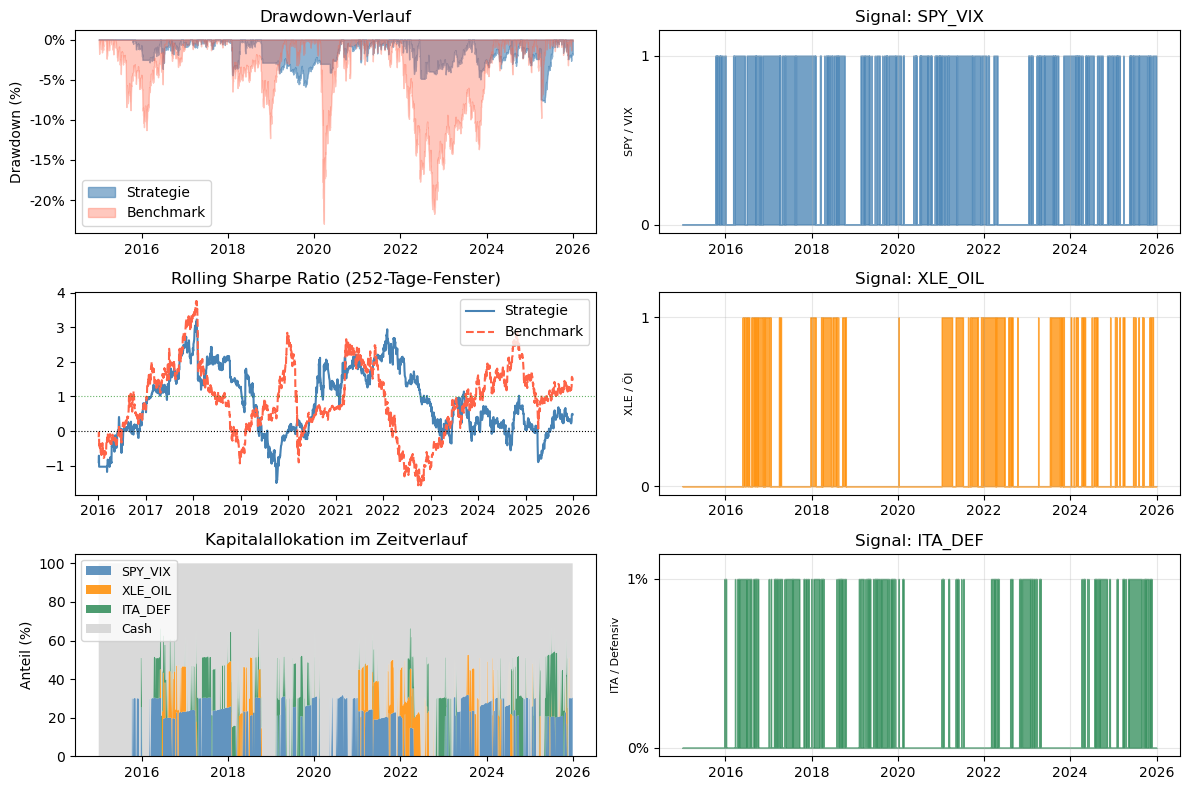

'\nport_yr  = yearly_return(port_ret,  dates_ret)\nbench_yr = yearly_return(bench_ret, dates_ret)\nyears    = sorted(set(port_yr) & set(bench_yr))\nx        = np.arange(len(years))\n\nfig, ax = plt.subplots(figsize=(12, 5))\nax.bar(x - 0.2, [port_yr[y]  for y in years], 0.38, color="steelblue", alpha=0.85, label="Strategie")\nax.bar(x + 0.2, [bench_yr[y] for y in years], 0.38, color="tomato",    alpha=0.75, label="Benchmark")\nax.axhline(0, color="black", linewidth=0.8)\nax.set_xticks(x); ax.set_xticklabels(years, rotation=45)\npct_labels(ax)\nax.set_title("Jährliche Renditen")\nax.legend(); ax.grid(axis="y", alpha=0.4)\nplt.tight_layout(); plt.show()\n\n\n# ═══════════════════════════════════════════════════════════════════════════\n# PLOT 6 – Return-Verteilung\n# ═══════════════════════════════════════════════════════════════════════════\n\nfig, ax = plt.subplots(figsize=(10, 5))\nfor ret, label, color in [\n    (port_ret  * 100, "Strategie",  "steelblue"),\n    (bench_ret * 100, "Be

In [41]:
## Grafiken Neu:
dates  = df_prices.index.to_numpy()

port   = np.array(portfolio_curve)
bench  = np.array(benchmark_curve)

port_ret  = np.diff(port)  / port[:-1]
bench_ret = np.diff(bench) / bench[:-1]
dates_ret = dates[1:]

prices = {t: df_prices[t].to_numpy()          for t in tickers[:-1]}
signal = {t: df_position_open[t].to_numpy()   for t in tickers[:-1]}
change = {t: df_position_changes[t].to_numpy() for t in tickers[:-1]}

alloc_cols   = tickers[:-1] + ["cash"]
alloc        = np.column_stack([df_position[c].to_numpy() for c in alloc_cols])
alloc_pct    = alloc / alloc.sum(axis=1, keepdims=True) * 100

colors_sig   = ["steelblue", "darkorange", "seagreen"]
signal_names = ["SPY / VIX", "XLE / Öl", "ITA / Defensiv"]


def drawdown(curve):
    return (curve - np.maximum.accumulate(curve)) / np.maximum.accumulate(curve) * 100

def rolling_sharpe(ret, w=252):
    n   = len(ret)
    out = np.full(n, np.nan)
    for i in range(w, n):
        r = ret[i-w:i]
        out[i] = (r.mean() * 252) / (r.std() * np.sqrt(252))
    return out

def normal_pdf(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

def pct_labels(ax, axis="y", decimals=0):
    if axis == "y":
        ax.set_yticklabels([f"{v:.{decimals}f}%" for v in ax.get_yticks()])
    else:
        ax.set_xticklabels([f"{v:.{decimals}f}%" for v in ax.get_xticks()])

def yearly_return(ret, dates):
    years  = np.array([d.year for d in dates])
    unique = sorted(set(years))
    result = {}
    for y in unique:
        mask     = years == y
        result[y] = (np.prod(1 + ret[mask]) - 1) * 100
    return result


# ═══════════════════════════════════════════════════════════════════════════
# PLOT 1 – Drawdown
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3,2,figsize=(12, 8))
axes[0,0].fill_between(dates, drawdown(port),  alpha=0.6,  color="steelblue", label="Strategie")
axes[0,0].fill_between(dates, drawdown(bench), alpha=0.35, color="tomato",    label="Benchmark")
pct_labels(axes[0,0])
axes[0,0].set_title("Drawdown-Verlauf")
axes[0,0].set_ylabel("Drawdown (%)")
axes[0,0].legend(); ax.grid(alpha=0.4)
plt.tight_layout(); 


# ═══════════════════════════════════════════════════════════════════════════
# PLOT 2 – Rolling Sharpe Ratio
# ═══════════════════════════════════════════════════════════════════════════

axes[1,0].plot(dates_ret, rolling_sharpe(port_ret),  color="steelblue", label="Strategie")
axes[1,0].plot(dates_ret, rolling_sharpe(bench_ret), color="tomato", linestyle="--", label="Benchmark")
axes[1,0].axhline(0, color="black", linewidth=0.8, linestyle=":")
axes[1,0].axhline(1, color="green", linewidth=0.8, linestyle=":", alpha=0.6)
axes[1,0].set_title("Rolling Sharpe Ratio (252-Tage-Fenster)")
axes[1,0].legend(); axes[0,1].grid(alpha=0.4)
plt.tight_layout(); 


# ═══════════════════════════════════════════════════════════════════════════
# PLOT 3 – Signal-Aktivität
# ═══════════════════════════════════════════════════════════════════════════


for i, (ticker, color, name) in enumerate(zip(tickers[:-1], colors_sig, signal_names)):
    ax = axes[i, 1]  # ← rechte Spalte, Zeilen 0,1,2
    ax.fill_between(dates, signal[ticker], step="post", alpha=0.75, color=color)
    ax.set_ylabel(name, fontsize=8)
    ax.set_ylim(-0.05, 1.15)
    ax.set_yticks([0, 1])
    ax.grid(alpha=0.3)
    axes[i,1].set_title(f"Signal: {ticker}")

# ═══════════════════════════════════════════════════════════════════════════
# PLOT 4 – Kapitalallokation (Stacked Area)
# ═══════════════════════════════════════════════════════════════════════════

axes[2,0].stackplot(dates, alloc_pct.T,
             labels=tickers[:-1] + ["Cash"],
             colors=colors_sig + ["lightgrey"], alpha=0.85)
pct_labels(ax)
axes[2,0].set_title("Kapitalallokation im Zeitverlauf")
axes[2,0].set_ylabel("Anteil (%)")
axes[2,0].legend(loc="upper left", fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# PLOT 5 – Jährliche Renditen
# ═══════════════════════════════════════════════════════════════════════════
"""
port_yr  = yearly_return(port_ret,  dates_ret)
bench_yr = yearly_return(bench_ret, dates_ret)
years    = sorted(set(port_yr) & set(bench_yr))
x        = np.arange(len(years))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.2, [port_yr[y]  for y in years], 0.38, color="steelblue", alpha=0.85, label="Strategie")
ax.bar(x + 0.2, [bench_yr[y] for y in years], 0.38, color="tomato",    alpha=0.75, label="Benchmark")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(years, rotation=45)
pct_labels(ax)
ax.set_title("Jährliche Renditen")
ax.legend(); ax.grid(axis="y", alpha=0.4)
plt.tight_layout(); plt.show()

""""""
# ═══════════════════════════════════════════════════════════════════════════
# PLOT 6 – Return-Verteilung
# ═══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 5))
for ret, label, color in [
    (port_ret  * 100, "Strategie",  "steelblue"),
    (bench_ret * 100, "Benchmark",  "tomato"),
]:
    mu, sigma = ret.mean(), ret.std()
    x_range   = np.linspace(ret.min(), ret.max(), 300)
    ax.hist(ret, bins=80, density=True, alpha=0.35, color=color)
    ax.plot(x_range, normal_pdf(x_range, mu, sigma), color=color, linewidth=2,
            label=f"{label}  (μ={mu:.2f}%, σ={sigma:.2f}%)")
    ax.axvline(mu, color=color, linestyle="--", linewidth=1, alpha=0.7)
ax.set_title("Verteilung der täglichen Renditen")
ax.set_xlabel("Tagesrendite (%)")
ax.set_ylabel("Dichte")
ax.legend(fontsize=9); ax.grid(alpha=0.4)
pct_labels(ax, axis="x", decimals=1)
plt.tight_layout(); plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# PLOT 7 – Kauf- und Verkaufszeitpunkte pro Signal
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, ticker, color, name in zip(axes, tickers[:-1], colors_sig, signal_names):
    p      = prices[ticker] / prices[ticker][0]   # normiert
    sig    = signal[ticker]
    chg    = change[ticker]

    ax.plot(dates, p, color=color, linewidth=1.2, label="Kurs (normiert)")
    ax.fill_between(dates, 0, p.max() * 1.05,
                    where=sig == 1, alpha=0.12, color=color, step="post", label="Signal aktiv")

    buy_idx  = np.where(chg ==  1)[0]
    sell_idx = np.where(chg == -1)[0]
    ax.scatter(dates[buy_idx],  p[buy_idx],  marker="^", color="green", s=60, zorder=5, label="Kauf")
    ax.scatter(dates[sell_idx], p[sell_idx], marker="v", color="red",   s=60, zorder=5, label="Verkauf")

    ax.set_title(f"Signal – {name}", fontsize=10)
    ax.set_ylabel("Normierter Kurs")
    ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=0.3)

axes[-1].set_xlabel("Datum")
fig.suptitle("Kauf- und Verkaufszeitpunkte pro Signal", fontsize=13)
plt.tight_layout(); plt.show()
"""


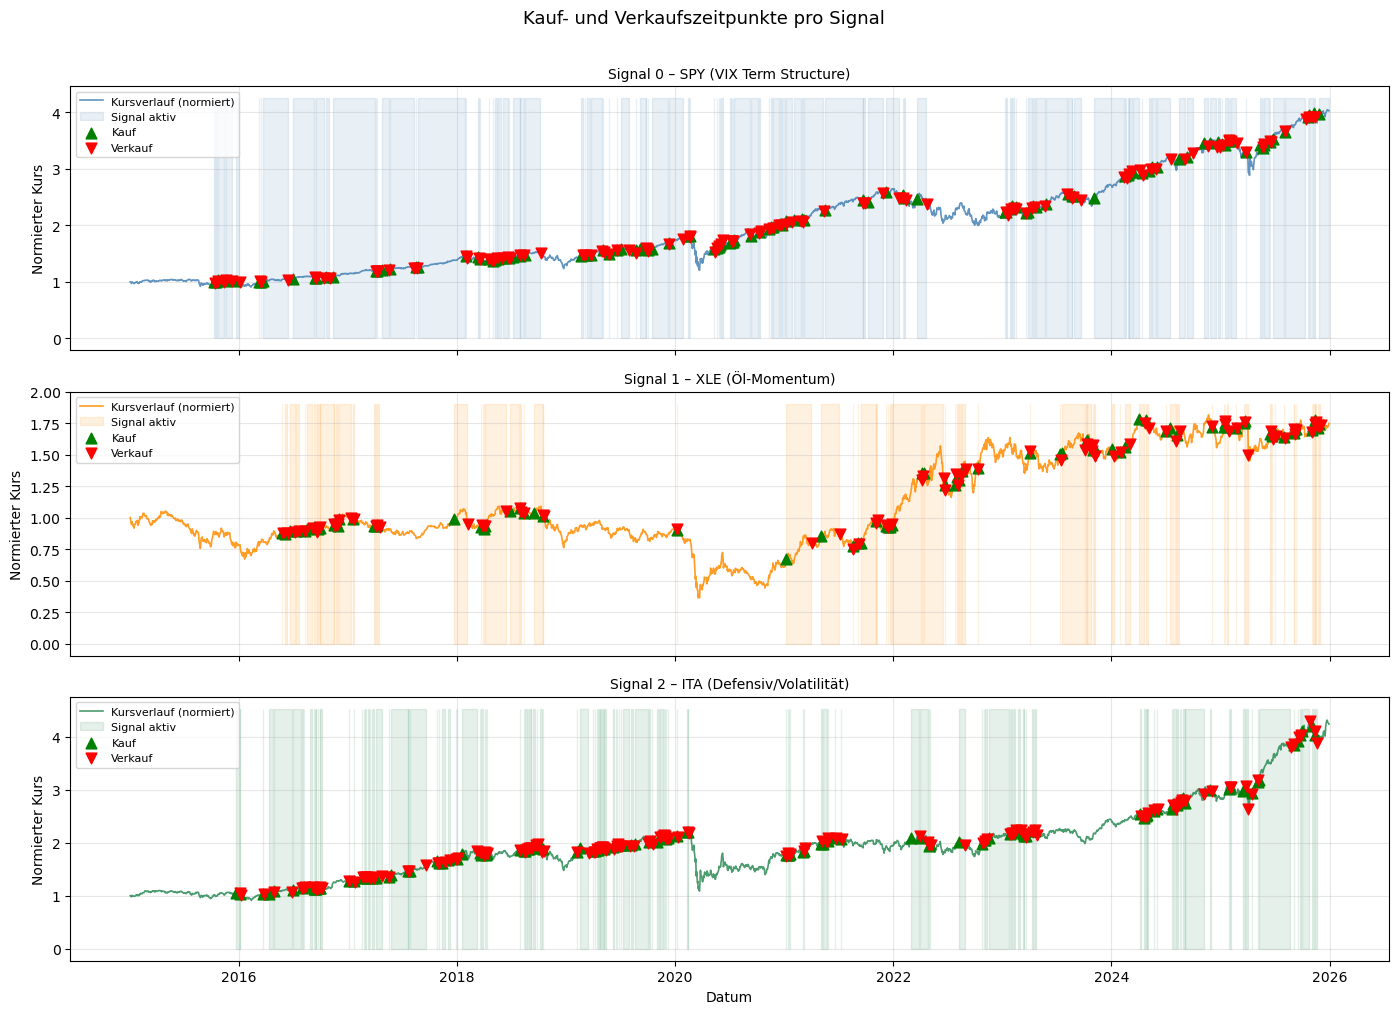

In [15]:
# anzeige wann aktie gekauft wird
signal_meta = [
    (tickers[0], "Signal 0 – SPY (VIX Term Structure)", "steelblue"),
    (tickers[1], "Signal 1 – XLE (Öl-Momentum)",        "darkorange"),
    (tickers[2], "Signal 2 – ITA (Defensiv/Volatilität)","seagreen"),
]
 
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
 
for ax, (ticker, title, color) in zip(axes, signal_meta):
 
    # Normierter Kursverlauf (Startwert = 1)
    price = df_prices[ticker]
    price_norm = price / price.iloc[0]
 
    ax.plot(price.index, price_norm, color=color, linewidth=1.2,
            alpha=0.85, label="Kursverlauf (normiert)")
 
    # Hintergrund einfärben wenn Signal aktiv
    signal = df_position_open[ticker]
    ax.fill_between(signal.index, 0, price_norm.max() * 1.05,
                    where=signal == 1,
                    alpha=0.12, color=color, step="post", label="Signal aktiv")
 
    # Kaufzeitpunkte (0 → 1)
    changes      = df_position_changes[ticker]
    buy_dates    = changes[changes == 1].index
    sell_dates   = changes[changes == -1].index
 
    ax.scatter(buy_dates,  price_norm.loc[buy_dates],
               marker="^", color="green", s=60, zorder=5, label="Kauf")
    ax.scatter(sell_dates, price_norm.loc[sell_dates],
               marker="v", color="red",   s=60, zorder=5, label="Verkauf")
 
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Normierter Kurs")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)
 
axes[-1].set_xlabel("Datum")
fig.suptitle("Kauf- und Verkaufszeitpunkte pro Signal", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
